# Fairness, Economics, and Retention Policy

## Executive summary

Predictive ranking is not an operating policy. This notebook combines
descriptive subgroup diagnostics, explicit cost uncertainty, intervention
capacity, and governance rules. The selected policy reviews at most 700
employees, stays within a $1.75 million budget, requires positive expected
value, and permits human review only.

The data are synthetic, subgroup gaps are screening signals rather than legal
fairness verdicts, and modeled intervention value is not observed causal
impact.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "config" / "portfolio_notebooks.yaml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the project repository.")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Subgroup diagnostics

The selected model is compared with a sensitivity variant that excludes age
and education. Metrics use only the 2024 validation period.

In [2]:
fairness_models = pd.read_csv(
    PROCESSED / "retention_fairness_model_comparison.csv"
)
display(
    fairness_models[
        [
            "model_variant",
            "brier_score",
            "pr_auc",
            "roc_auc",
            "top_fraction_precision",
            "top_fraction_capture",
            "selected_for_use",
        ]
    ].round(3)
)

,model_variant,brier_score,pr_auc,roc_auc,top_fraction_precision,top_fraction_capture,selected_for_use
0,Selected model,0.093,0.164,0.621,0.197,0.186,True
1,Age and education excluded,0.093,0.167,0.620,0.201,0.189,False


In [3]:
disparities = pd.read_csv(
    PROCESSED / "retention_fairness_disparities.csv"
)
selected_disparities = disparities.loc[
    disparities["model_variant"].eq("Selected model")
].copy()
display(
    selected_disparities[
        [
            "attribute",
            "eligible_groups",
            "demographic_parity_difference",
            "equal_opportunity_difference",
            "maximum_absolute_calibration_gap",
            "screening_review_flag",
            "review_triggers",
        ]
    ].round(3)
)

,attribute,eligible_groups,demographic_parity_difference,equal_opportunity_difference,maximum_absolute_calibration_gap,screening_review_flag,review_triggers
0,age_band,5,0.030,0.078,0.011,False,NaN
1,education_level,4,0.036,0.048,0.039,False,NaN
2,region,4,0.156,0.263,0.019,True,"demographic_parity, equal_opportunity, false_p..."
3,employment_type,2,0.196,0.281,0.006,True,"demographic_parity, equal_opportunity, false_p..."
4,department_name,8,0.434,0.542,0.028,True,"demographic_parity, equal_opportunity, false_p..."
5,job_level,3,0.224,0.353,0.018,True,"demographic_parity, equal_opportunity, false_p..."
6,organizational_level,2,0.080,0.177,0.035,True,equal_opportunity


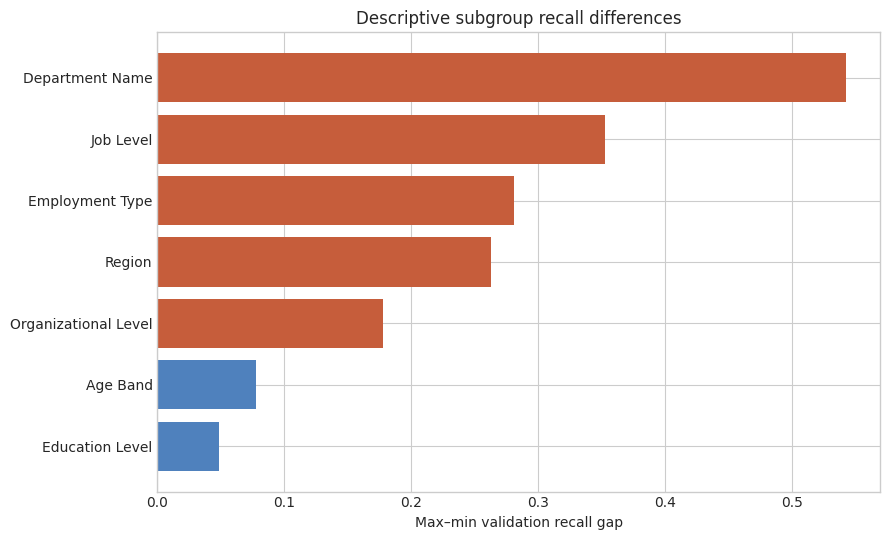

In [4]:
plot_disparities = selected_disparities.sort_values(
    "equal_opportunity_difference"
).assign(
    attribute_label=lambda frame: (
        frame["attribute"].str.replace("_", " ").str.title()
    )
)

plt.figure(figsize=(9, 5.5))
plt.barh(
    plot_disparities["attribute_label"],
    plot_disparities["equal_opportunity_difference"],
    color=plot_disparities["screening_review_flag"].map(
        {True: "#c65d3b", False: "#4f81bd"}
    ),
)
plt.xlabel("Max–min validation recall gap")
plt.title("Descriptive subgroup recall differences")
plt.tight_layout()
plt.show()

Removing age and education does not remove proxy relationships or consistently
reduce disparities. Flagged attributes require investigation, additional data,
and domain review; they do not prove discrimination.

## Economic assumptions

Three replacement-impact scenarios, three intervention costs, and three
effectiveness assumptions create 27 combinations. Operational units remain
separate from dollars to avoid double counting.

In [5]:
assumptions = pd.read_csv(
    PROCESSED / "retention_cost_assumption_table.csv"
)
display(assumptions)

,assumption_family,scenario,salary_multiplier,intervention_cost_usd,success_probability,vacancy_days,time_to_productivity_days,training_hours_per_replacement,coverage_hours_per_replacement
0,Replacement impact,Low,0.5,NaN,NaN,30.0,60.0,40.0,60.0
1,Replacement impact,Base,1.0,NaN,NaN,60.0,90.0,80.0,180.0
2,Replacement impact,High,1.5,NaN,NaN,90.0,150.0,120.0,360.0
3,Intervention cost,Lean,NaN,1000.0,NaN,NaN,NaN,NaN,NaN
4,Intervention cost,Standard,NaN,2500.0,NaN,NaN,NaN,NaN,NaN
5,Intervention cost,Intensive,NaN,5000.0,NaN,NaN,NaN,NaN,NaN
6,Intervention effectiveness,Conservative,NaN,NaN,0.10,NaN,NaN,NaN,NaN
7,Intervention effectiveness,Base,NaN,NaN,0.25,NaN,NaN,NaN,NaN
8,Intervention effectiveness,Optimistic,NaN,NaN,0.40,NaN,NaN,NaN,NaN


In [6]:
scenario_counts = (
    assumptions.groupby("assumption_family", as_index=False)
    .agg(scenarios=("scenario", "nunique"))
)
scenario_counts.loc[len(scenario_counts)] = [
    "Full cross-product",
    int(scenario_counts["scenarios"].prod()),
]
display(scenario_counts)

,assumption_family,scenarios
0,Intervention cost,3
1,Intervention effectiveness,3
2,Replacement impact,3
3,Full cross-product,27


The reference case uses a replacement impact equal to annual salary, a $2,500
intervention cost, and 25% intervention effectiveness. These are transparent
planning assumptions, not measured causal effects.

## Policy comparison

Six policies are evaluated on validation and then applied unchanged to the
once-only final test. A fixed 0.50 threshold is retained as an honest
comparison even though calibrated probabilities never reach it.

In [7]:
policies = pd.read_csv(PROCESSED / "retention_policy_comparison.csv")
policy_table = policies[
    [
        "evaluation_period",
        "policy",
        "selected_count",
        "precision",
        "capture_rate",
        "intervention_spend_usd",
        "expected_net_value_usd",
        "outcome_aligned_net_value_usd",
    ]
]
display(policy_table.round(2))

,evaluation_period,policy,selected_count,precision,capture_rate,intervention_spend_usd,expected_net_value_usd,outcome_aligned_net_value_usd
0,2024 validation,No intervention,0,0.00,0.00,0.0,0.00,0.0
1,2024 validation,Fixed 0.50 threshold,0,0.00,0.00,0.0,0.00,0.0
2,2024 validation,Validation cost-optimal threshold,2151,0.15,0.53,5377500.0,347361.86,717575.0
3,2024 validation,Top 10% probability,553,0.20,0.19,1382500.0,236302.68,514900.0
4,2024 validation,Top 700 probability,700,0.19,0.23,1750000.0,256904.82,594400.0
5,2024 validation,Budget-constrained expected value,700,0.12,0.15,1750000.0,840973.87,512125.0
6,2025 final test,No intervention,0,0.00,0.00,0.0,0.00,0.0
7,2025 final test,Fixed 0.50 threshold,0,0.00,0.00,0.0,0.00,0.0
8,2025 final test,Validation cost-optimal threshold,3294,0.15,0.62,8235000.0,1805732.86,2247675.0
9,2025 final test,Top 10% probability,665,0.20,0.16,1662500.0,894719.69,779925.0


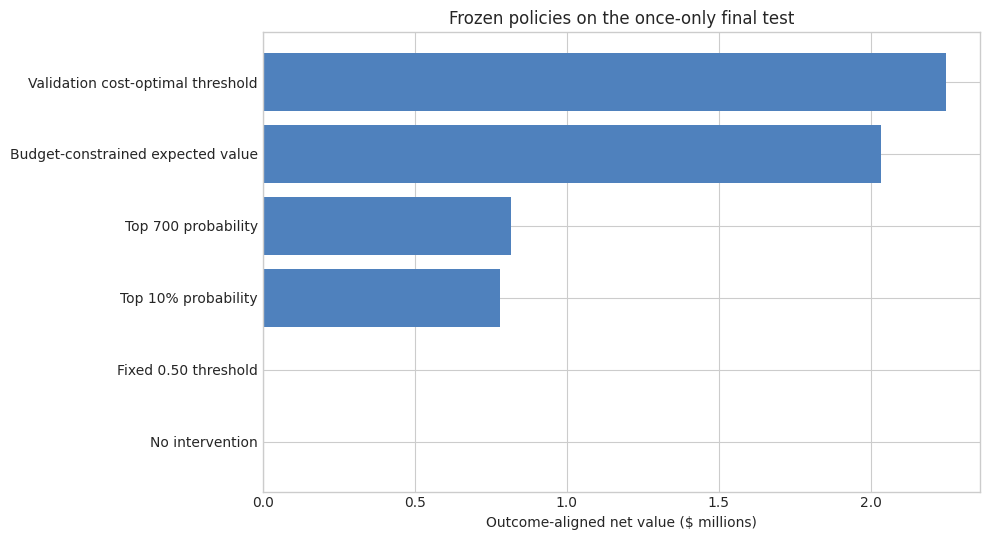

In [8]:
test_policies = policies.loc[
    policies["evaluation_period"].eq("2025 final test")
].sort_values("outcome_aligned_net_value_usd")

plt.figure(figsize=(10, 5.5))
plt.barh(
    test_policies["policy"],
    test_policies["outcome_aligned_net_value_usd"] / 1_000_000,
    color="#4f81bd",
)
plt.xlabel("Outcome-aligned net value ($ millions)")
plt.title("Frozen policies on the once-only final test")
plt.tight_layout()
plt.show()

In [9]:
decision = pd.read_csv(PROCESSED / "retention_policy_decision.csv")
decision_fields = [
    "selected_policy_display_name",
    "maximum_employees",
    "budget_usd",
    "intervention_cost_usd",
    "success_probability",
    "policy_frozen_before_test",
    "test_evaluated_once",
    "test_capture_rate",
    "test_outcome_aligned_net_value_usd",
    "decision_status",
]
display(decision[decision_fields].T)

,0
selected_policy_display_name,Budget-constrained expected value
maximum_employees,700
budget_usd,1750000.0
intervention_cost_usd,2500.0
success_probability,0.25
policy_frozen_before_test,True
test_evaluated_once,True
test_capture_rate,0.17061
test_outcome_aligned_net_value_usd,2033700.0
decision_status,Final test completed; no retuning


In [10]:
sensitivity = pd.read_csv(
    PROCESSED / "retention_policy_sensitivity.csv"
)
selected_test = sensitivity.loc[
    sensitivity["evaluation_period"].eq("2025 final test")
    & sensitivity["policy_key"].eq("budget_expected_value")
]
sensitivity_summary = pd.DataFrame(
    {
        "cost_scenarios": [len(selected_test)],
        "positive_predicted_value_share": [
            selected_test["expected_net_value_usd"].gt(0).mean()
        ],
        "positive_outcome_aligned_value_share": [
            selected_test["outcome_aligned_net_value_usd"].gt(0).mean()
        ],
    }
)
display(sensitivity_summary.round(3))

,cost_scenarios,positive_predicted_value_share,positive_outcome_aligned_value_share
0,27,0.63,0.741


The selected expected-value policy does not simply take the highest
probabilities. It ranks positive expected value under the budget and capacity
constraints, so salary-dependent avoidable cost also matters.

## Governance boundaries

The current plan is decision support for supportive retention conversations.
It cannot authorize an employment decision.

In [11]:
current = pd.read_csv(
    PROCESSED / "current_retention_policy_summary.csv"
)
governance = current[
    [
        "snapshot_date",
        "eligible_employees",
        "selected_for_human_review",
        "intervention_budget_usd",
        "human_review_required",
        "automatic_employment_action_permitted",
    ]
]
display(governance)

,snapshot_date,eligible_employees,selected_for_human_review,intervention_budget_usd,human_review_required,automatic_employment_action_permitted
0,2026-06-30,7305,700,1750000.0,True,False


Required boundaries:

- Selection means eligibility for human review, not a prediction of intent.
- No termination, promotion, compensation, or disciplinary action may be
  automated.
- Missing protected attributes cannot be audited.
- Subgroup screening must be repeated when populations or policies change.
- Expected financial value depends on uncertain cost and effectiveness
  assumptions.

### Portfolio navigation

Previous: [Model Development and Final Evaluation](02_model_development_and_final_evaluation.ipynb)  
Next: [Current Manufacturing Workforce Stability Plan](04_current_workforce_stability_plan.ipynb)